# 15. #
This problem involves the Boston data set, which we saw in the lab
for this chapter. We will now try to predict per capita crime rate
using the other variables in this data set. In other words, per capita
crime rate is the response, and the other variables are the predictors.

(a) For each predictor, fit a simple linear regression model to predict
the response. Describe your results. In which of the models is
there a statistically significant association between the predictor
and the response? Create some plots to back up your assertions.

In [2]:
import pandas as pd
import numpy as np
from matplotlib.pyplot import subplots
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)
import statsmodels.api as sm

In [3]:
Boston = load_data('Boston')
Boston.head()


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


c:\Users\olive\.conda\envs\ISLP\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
c:\Users\olive\.conda\envs\ISLP\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


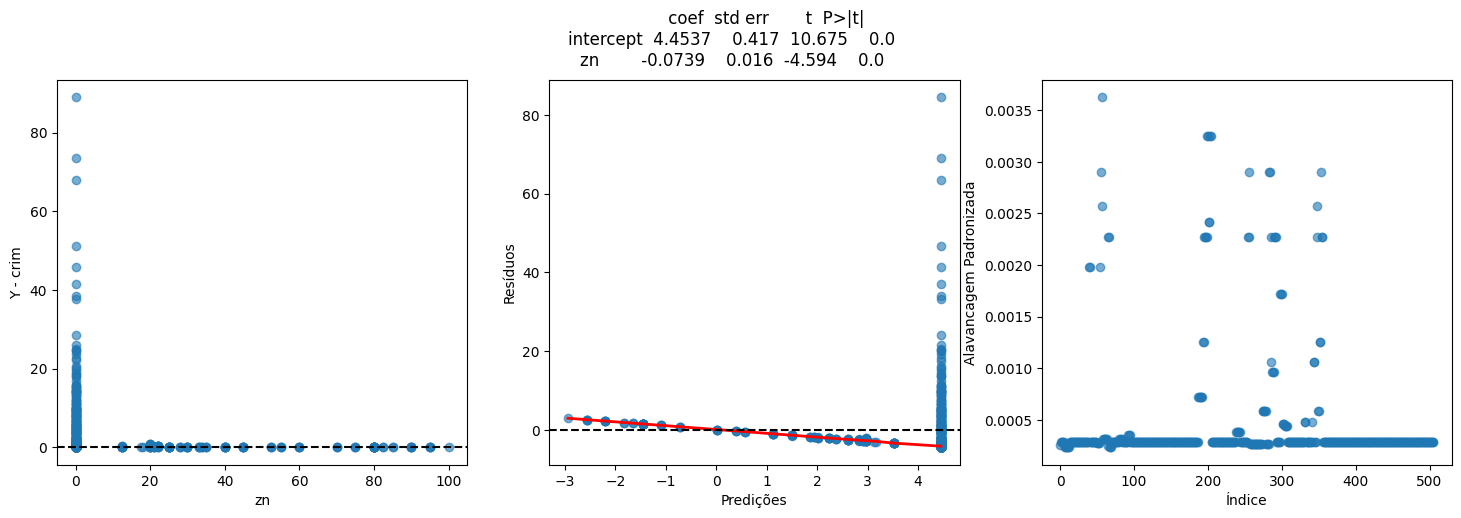

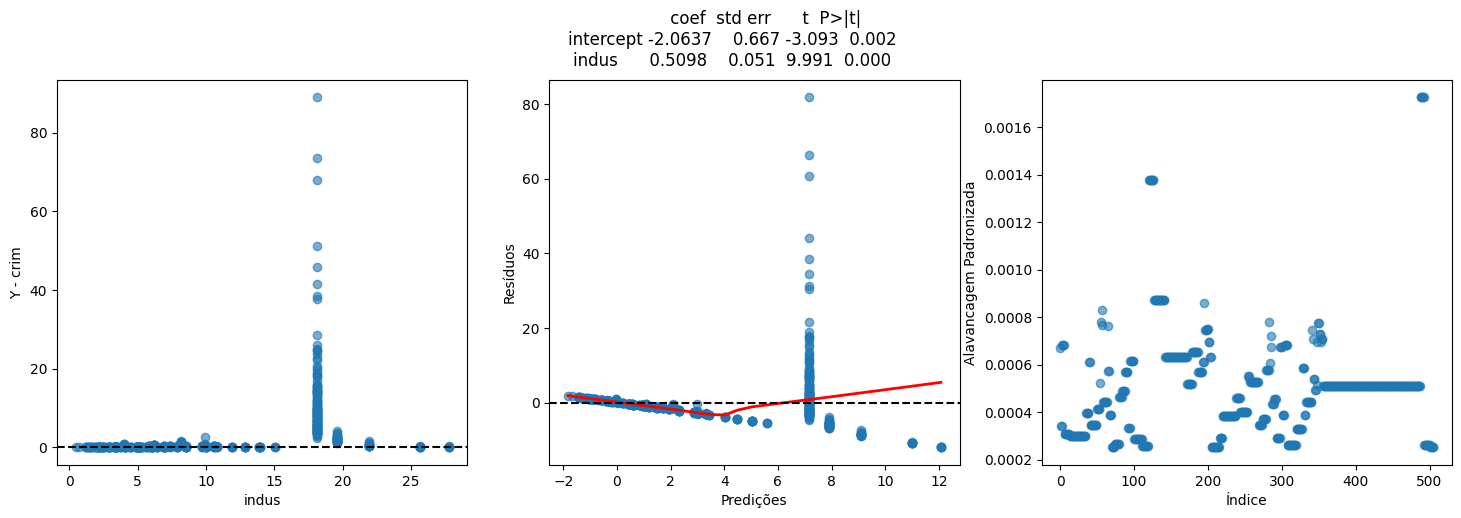

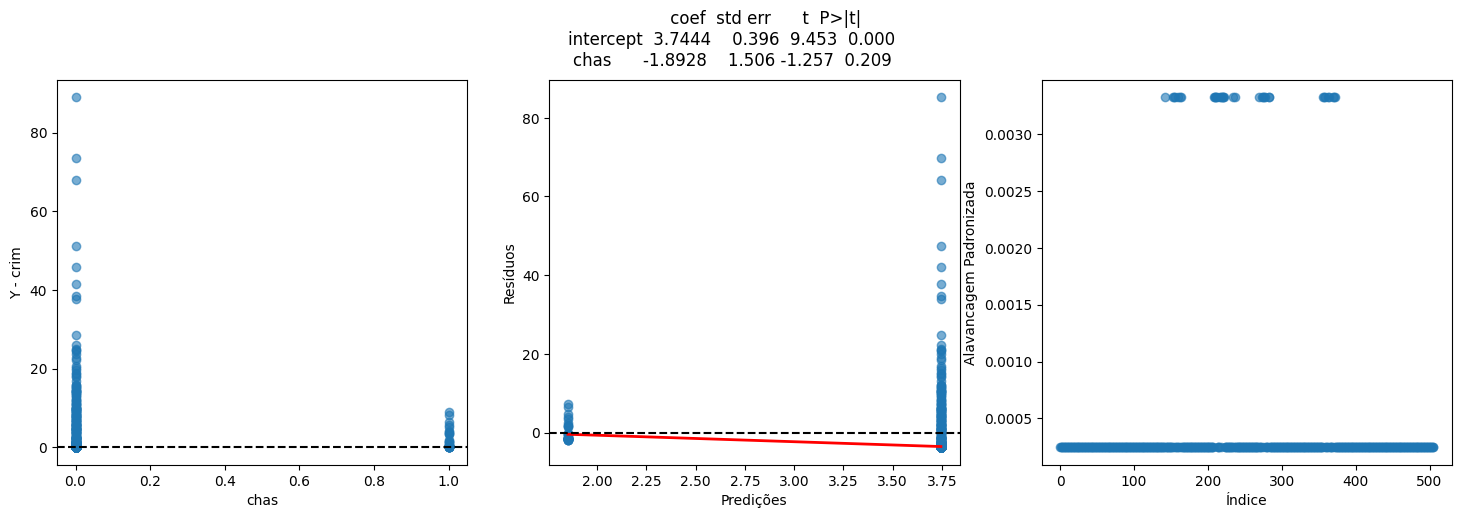

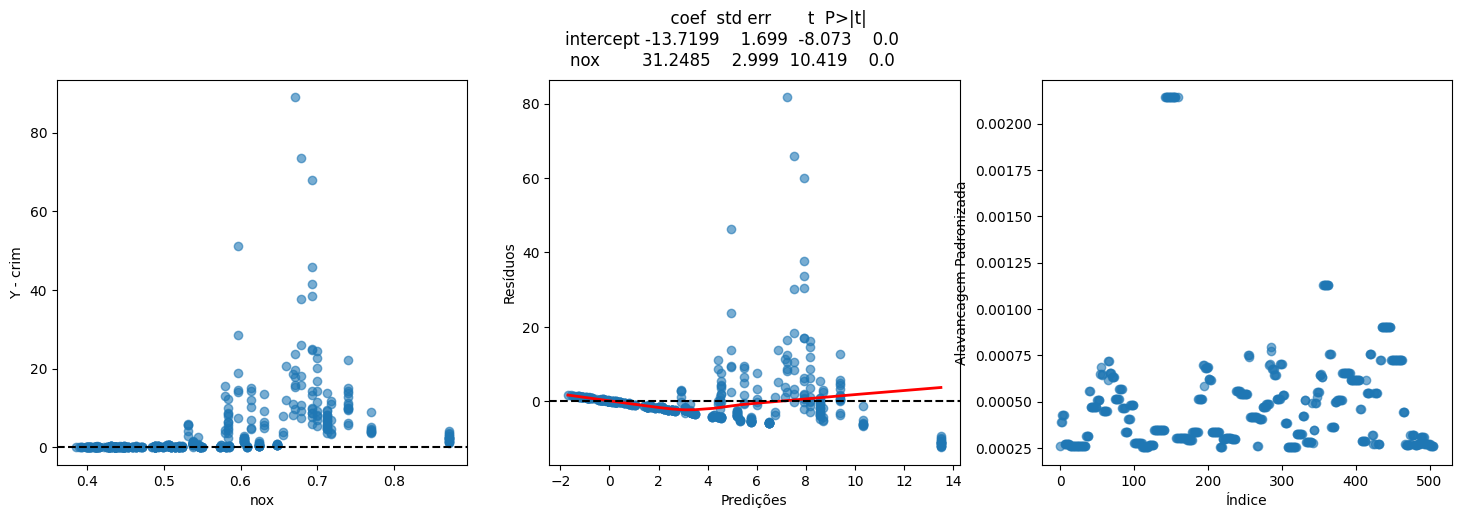

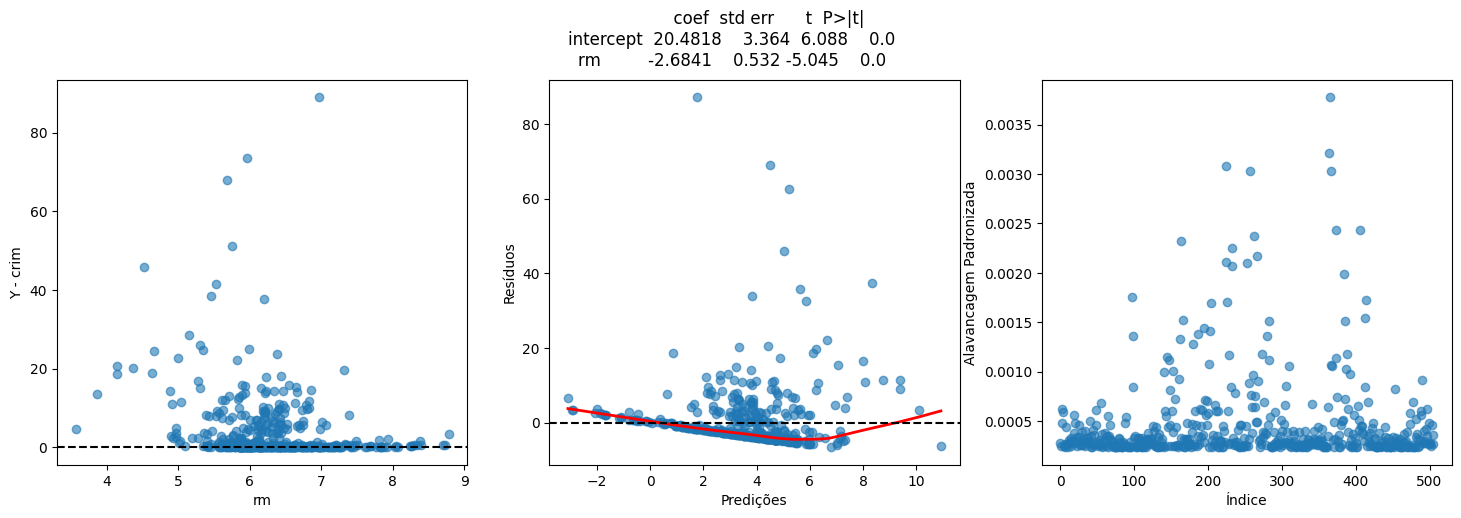

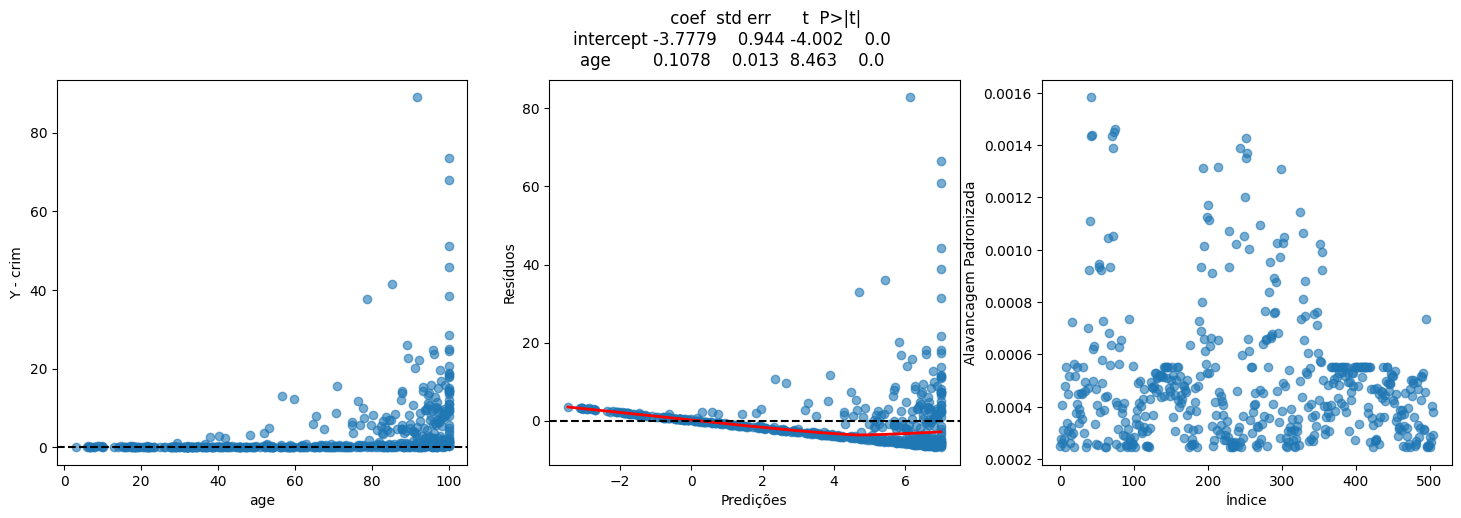

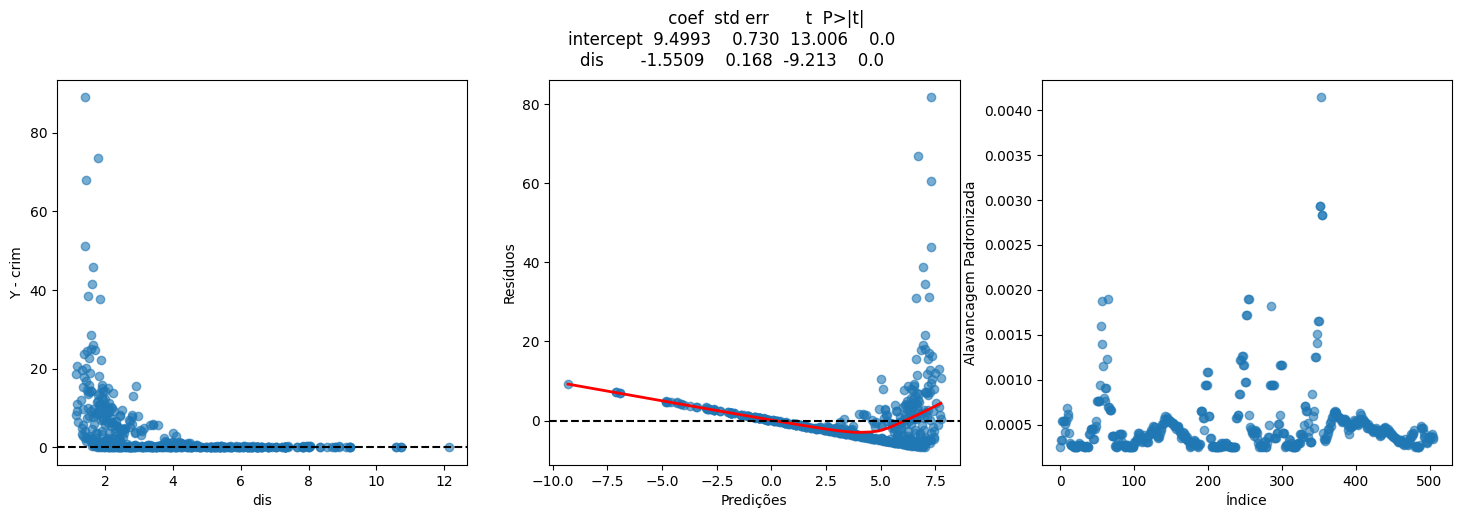

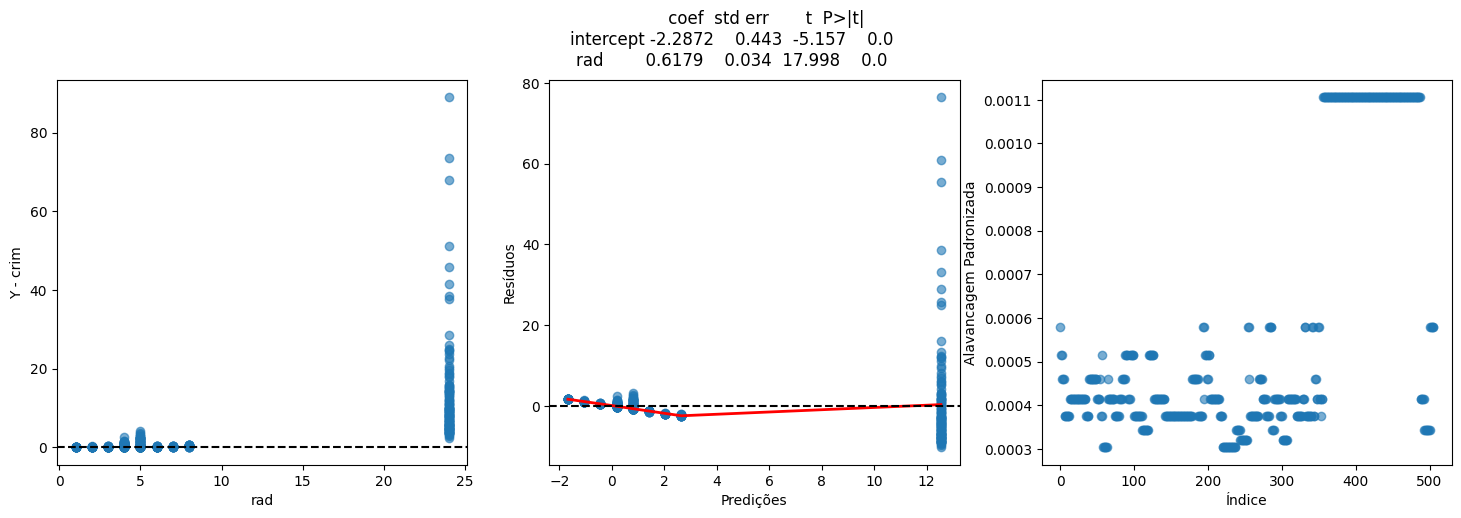

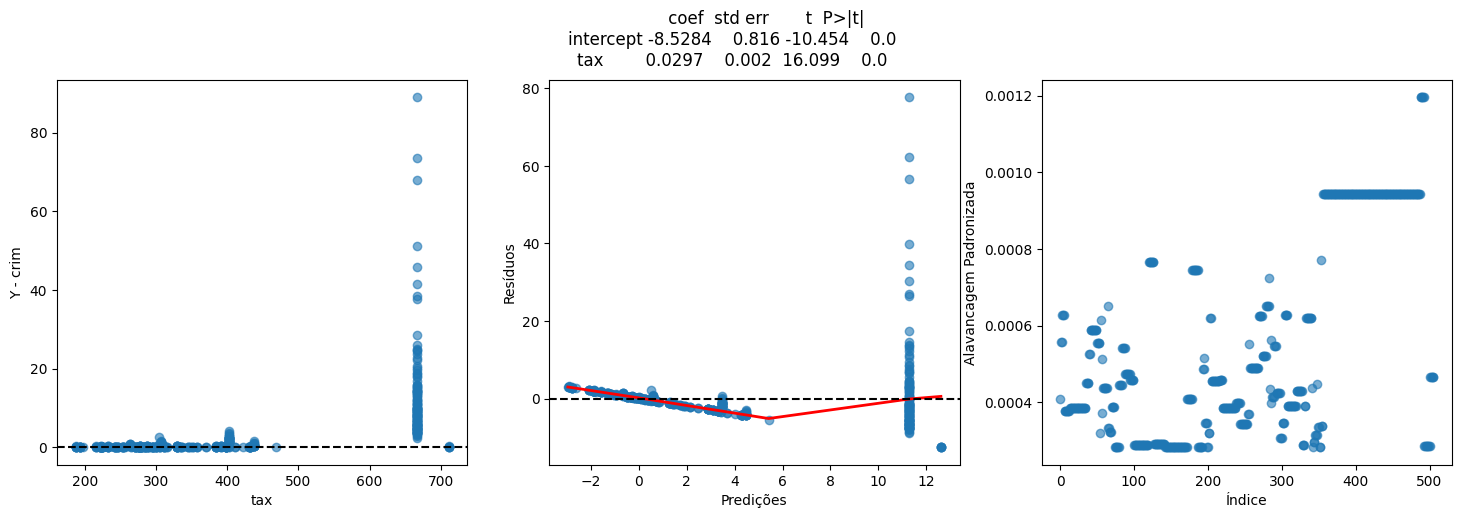

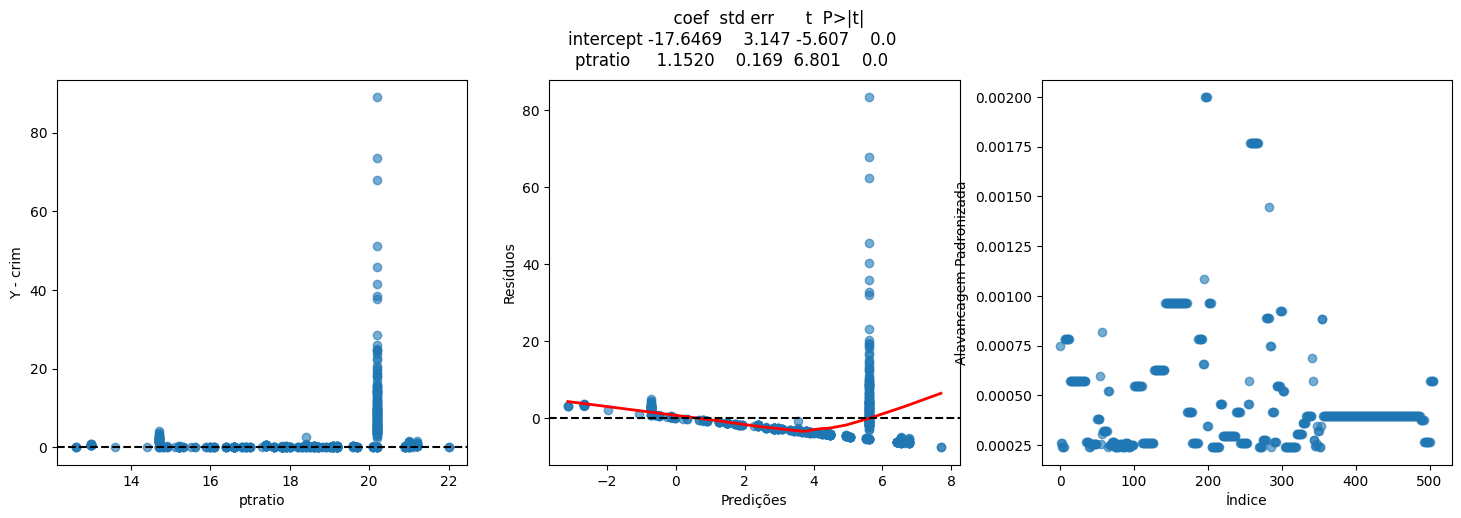

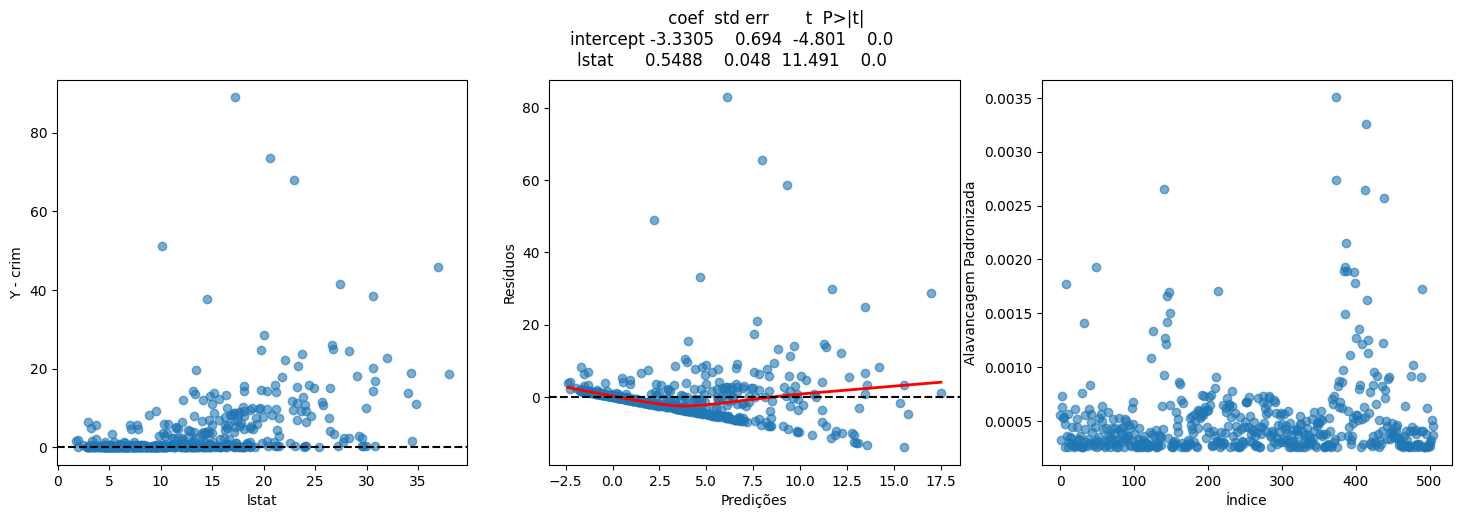

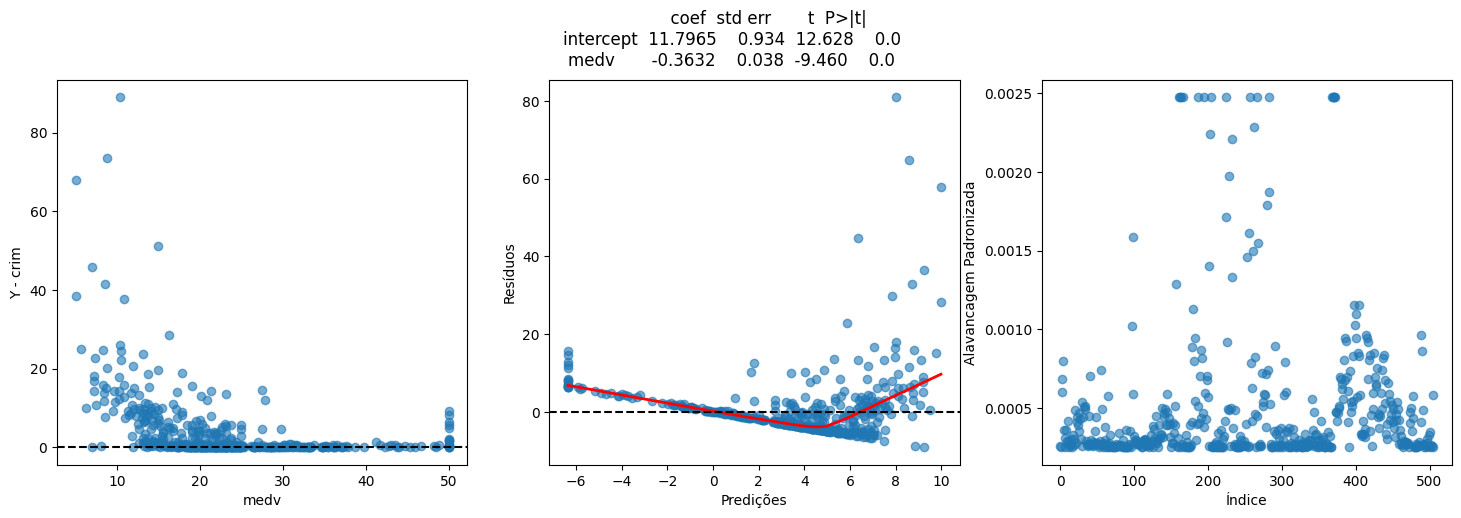

In [63]:
y = Boston['crim']
nomes_preditores = Boston.columns.drop('crim')
print()
res = list()
for nome_preditor in nomes_preditores:
    regression_results = sm.OLS(y, MS([nome_preditor]).fit_transform(Boston)).fit()
    res.append({'preditor':nome_preditor, 'resultado':regression_results, 
                'R2':regression_results.rsquared, 'T':regression_results.tvalues[nome_preditor], 
                'p-value':regression_results.pvalues[nome_preditor]})

def plot_y_preditor(y, preditor, nome_preditor, ax):
    ax.scatter(preditor, y, alpha=0.6)
    ax.set_xlabel(nome_preditor)
    ax.set_ylabel('Y - crim')
    ax.axhline(0, c='k',ls='--')

def plot_predicao_residuos(r, ax):
    ax.scatter(r.fittedvalues, r.resid, alpha=0.6);
    ax.set_xlabel('Predições')
    ax.set_ylabel('Resíduos')
    lowess = sm.nonparametric.lowess(r.resid, r.fittedvalues)
    ax.plot(lowess[:,0], lowess[:,1], color='red', lw='2');
    ax.axhline(0, c='k',ls='--')

def plot_alavancagem(r, ax):
    infl = r.get_influence()
    ax.scatter(np.arange(r.nobs), infl.hat_matrix_diag/np.sqrt(r.scale), alpha=0.6);
    ax.set_xlabel('Índice')
    ax.set_ylabel('Alavancagem Padronizada')
    np.argmax(infl.hat_matrix_diag)


for r in res:
    fig, ax = subplots(ncols=3, figsize=(18,5))
    fig.suptitle(f'{summarize(r['resultado'])}', y=1.02)
    plot_y_preditor(y, Boston[r['preditor']], r['preditor'], ax[0])
    plot_predicao_residuos(r['resultado'], ax[1])
    plot_alavancagem(r['resultado'], ax[2])


(b) Fit a multiple regression model to predict the response using
all of the predictors. Describe your results. For which predictors
can we reject the null hypothesis H0 : βj =0?

In [60]:
res_multi = sm.OLS(y, MS(nomes_preditores).fit_transform(Boston)).fit()
summarize(res_multi)

,coef,std err,t,P>|t|
intercept,13.7784,7.082,1.946,0.052
zn,0.0457,0.019,2.433,0.015
indus,-0.0584,0.084,-0.698,0.486
chas,-0.8254,1.183,-0.697,0.486
nox,-9.9576,5.290,-1.882,0.060
rm,0.6289,0.607,1.036,0.301
age,-0.0008,0.018,-0.047,0.962
dis,-1.0122,0.282,-3.584,0.000
rad,0.6125,0.088,6.997,0.000
tax,-0.0038,0.005,-0.730,0.466


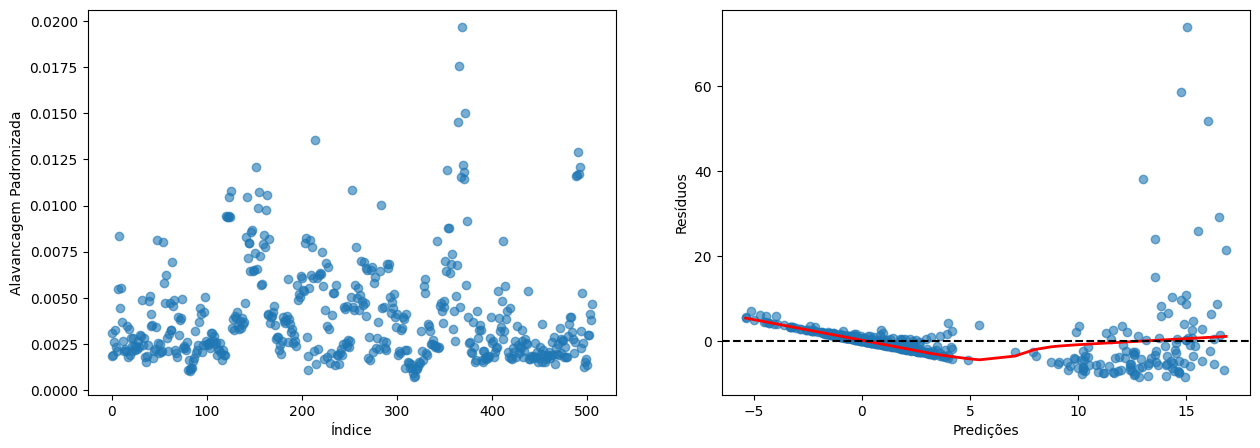

In [61]:
fig, ax = subplots(figsize=(15,5), ncols=2)
plot_alavancagem(res_multi, ax[0])
plot_predicao_residuos(res_multi,ax[1])

(c) How do your results from (a) compare to your results from (b)?
Create a plot displaying the univariate regression coefficients
from (a) on the x-axis, and the multiple regression coefficients
from (b) on the y-axis. That is, each predictor is displayed as a
single point in the plot. Its coefficient in a simple linear regres
sion model is shown on the x-axis, and its coefficient estimate
in the multiple linear regression model is shown on the y-axis.


C:\Users\olive\AppData\Local\Temp\ipykernel_8808\272578877.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coeficientes_univariada.append(r['resultado'].params[1])


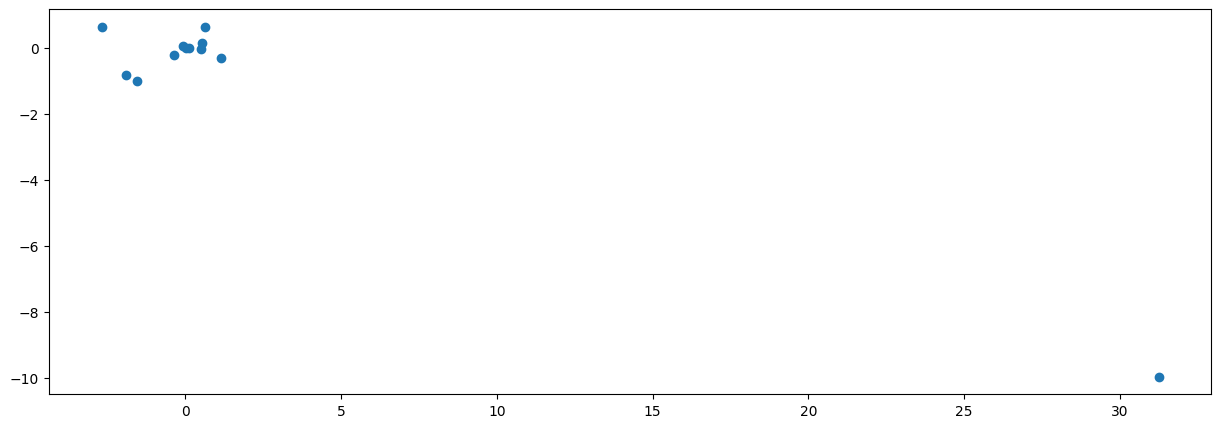

In [ ]:
coeficientes_univariada = []
for r in res:
    coeficientes_univariada.append(r['resultado'].params[1])

coeficientes_univariada
coeficientes_multivariada = res_multi.params[1:]

ax = subplots(figsize=(15,5))[1]
ax.scatter(coeficientes_univariada, coeficientes_multivariada)

(d) Is there evidence of non-linear association between any of the
predictors and the response? To answer this question, for each
predictor X, fit a model of the form
Y =β0+β1X+β2X2+β3X3+ϵ.

c:\Users\olive\.conda\envs\ISLP\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
c:\Users\olive\.conda\envs\ISLP\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


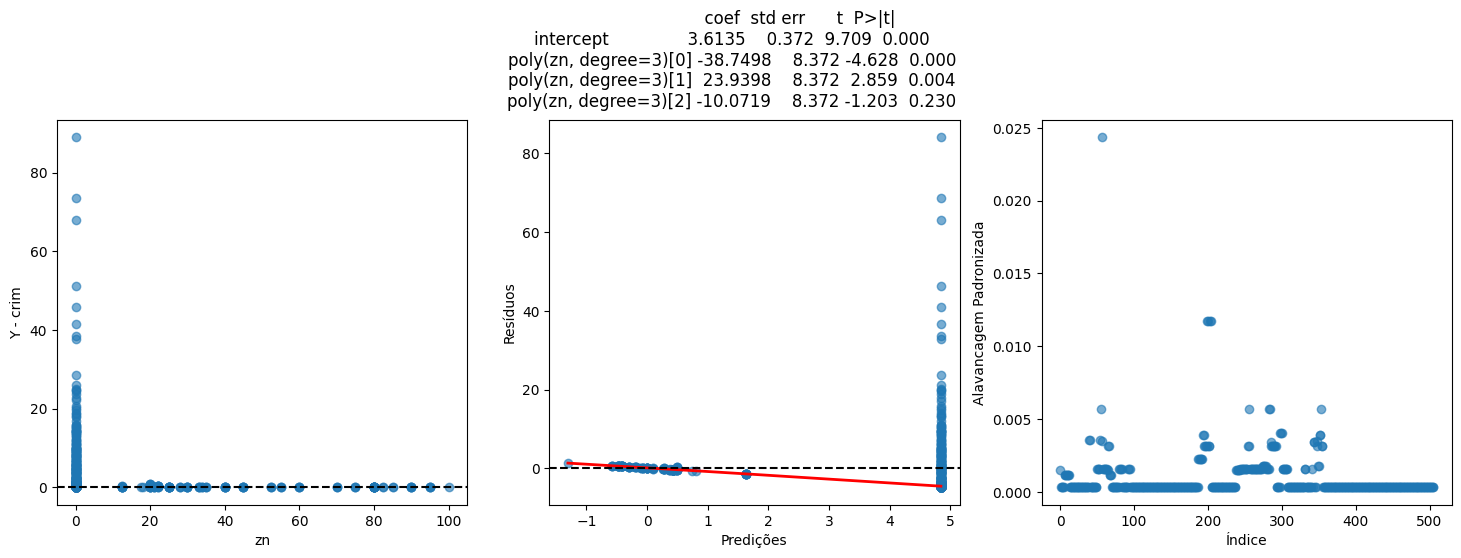

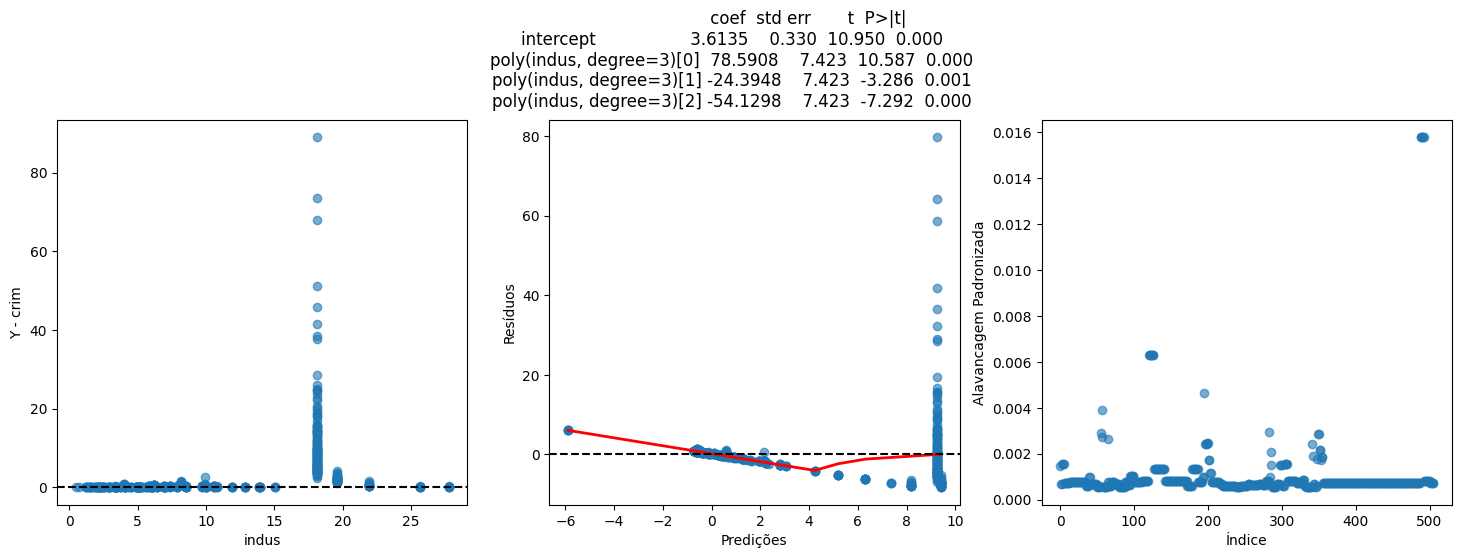

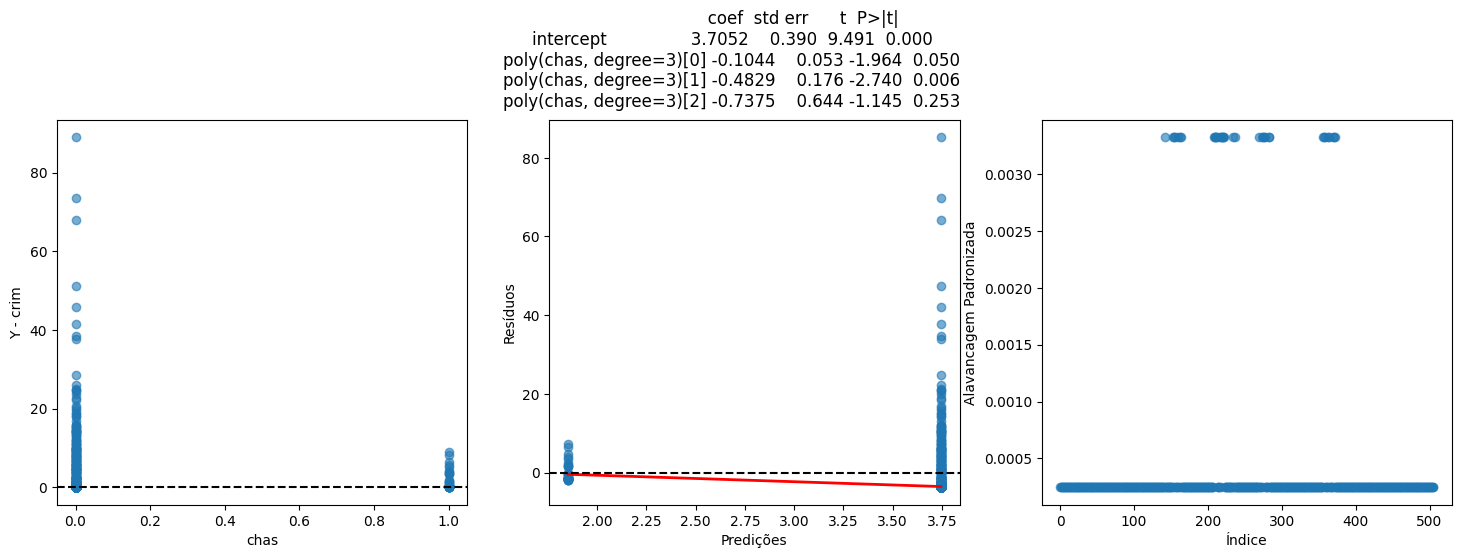

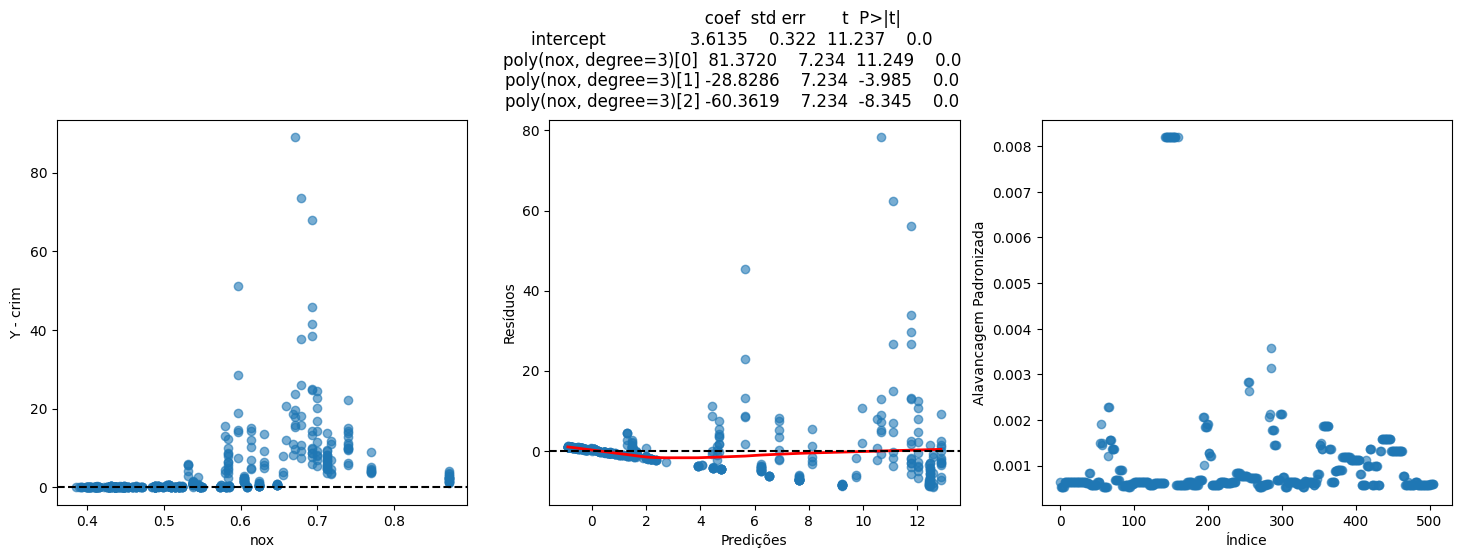

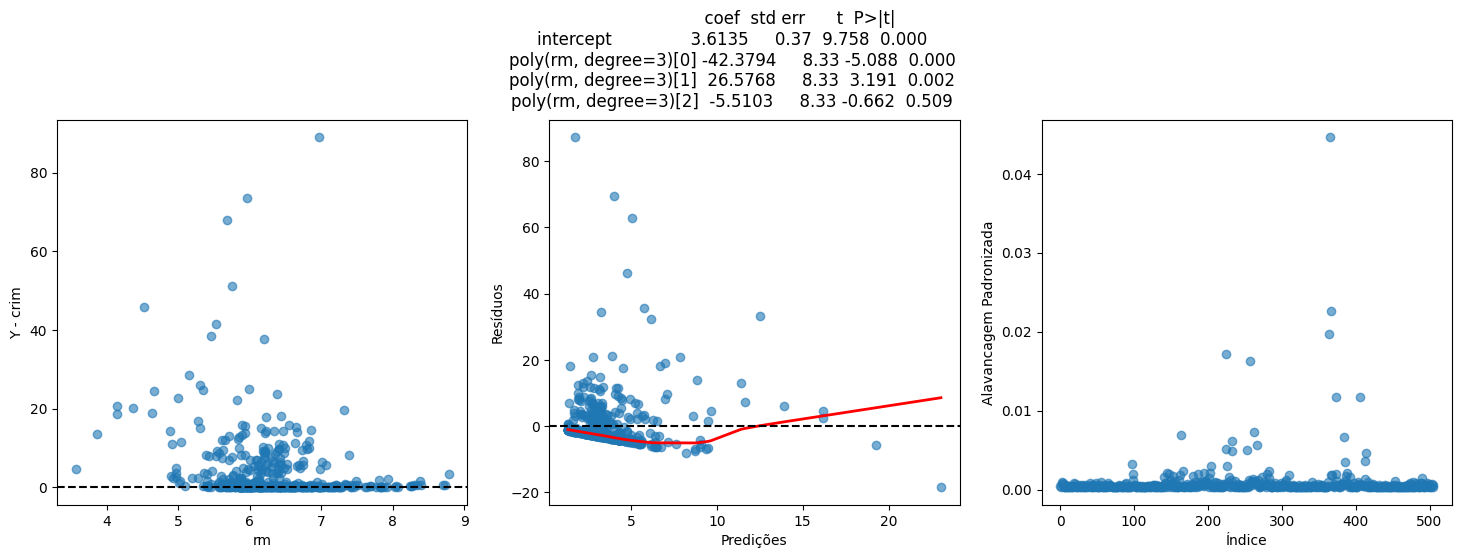

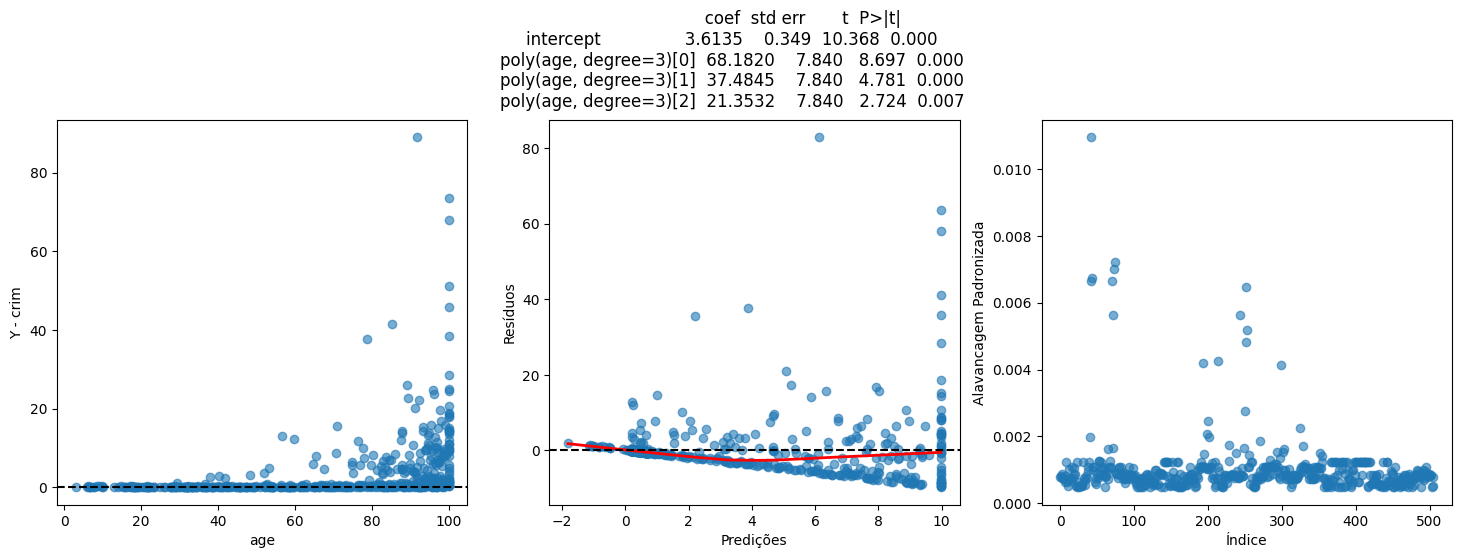

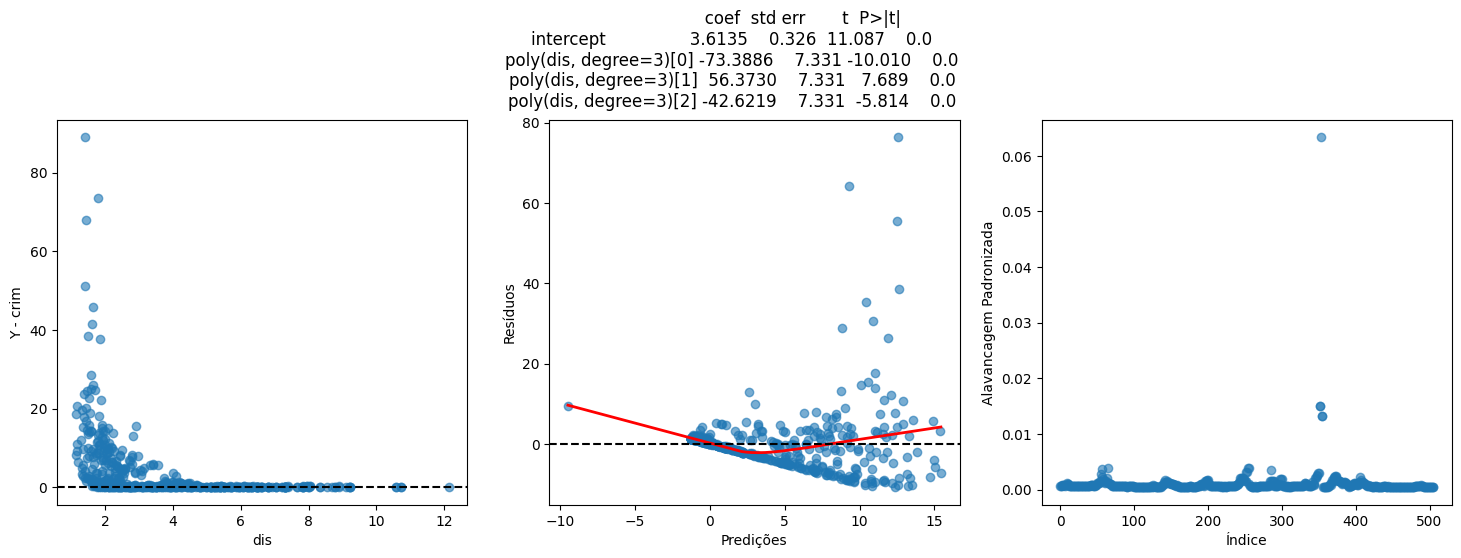

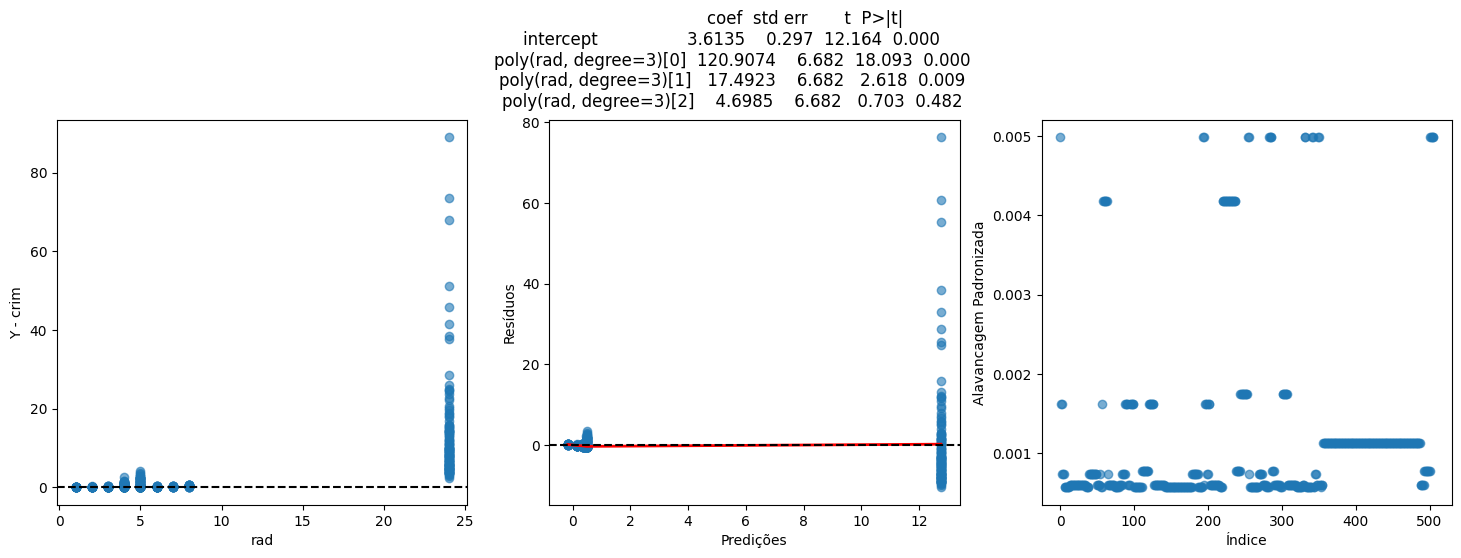

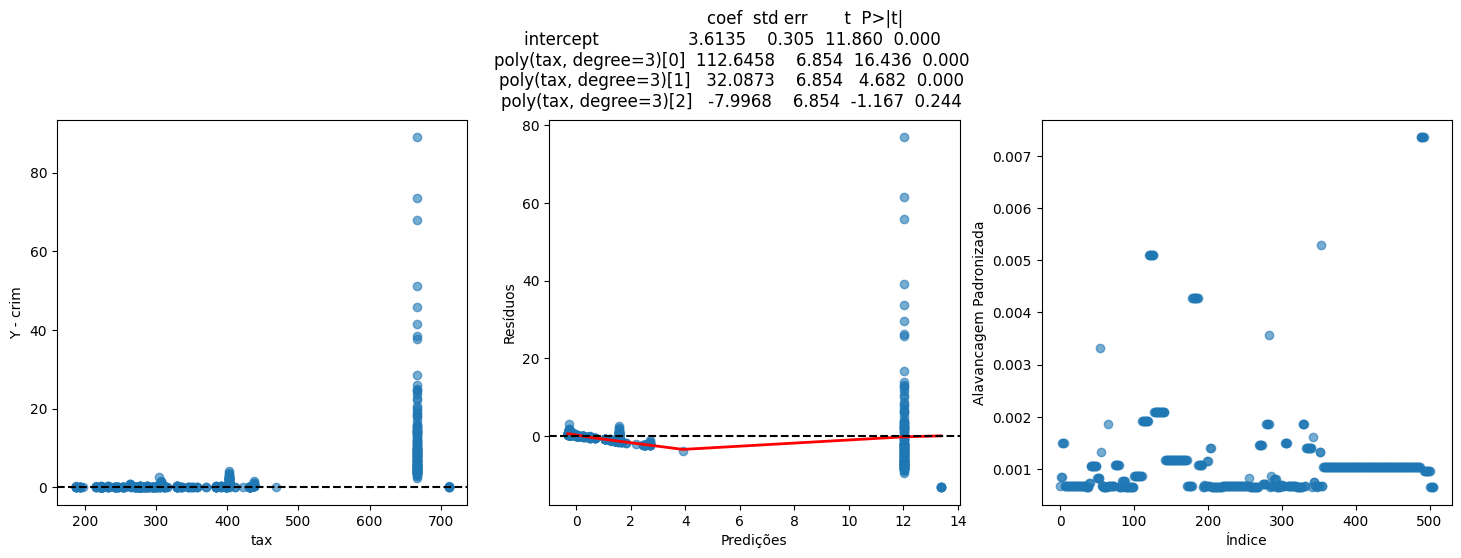

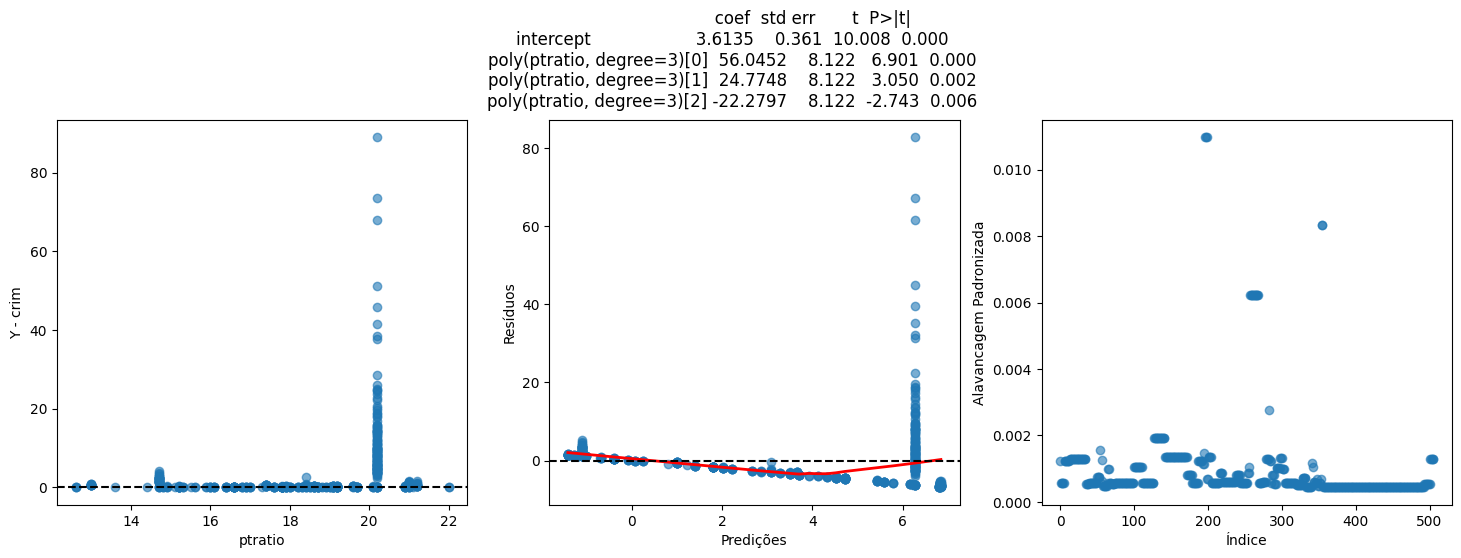

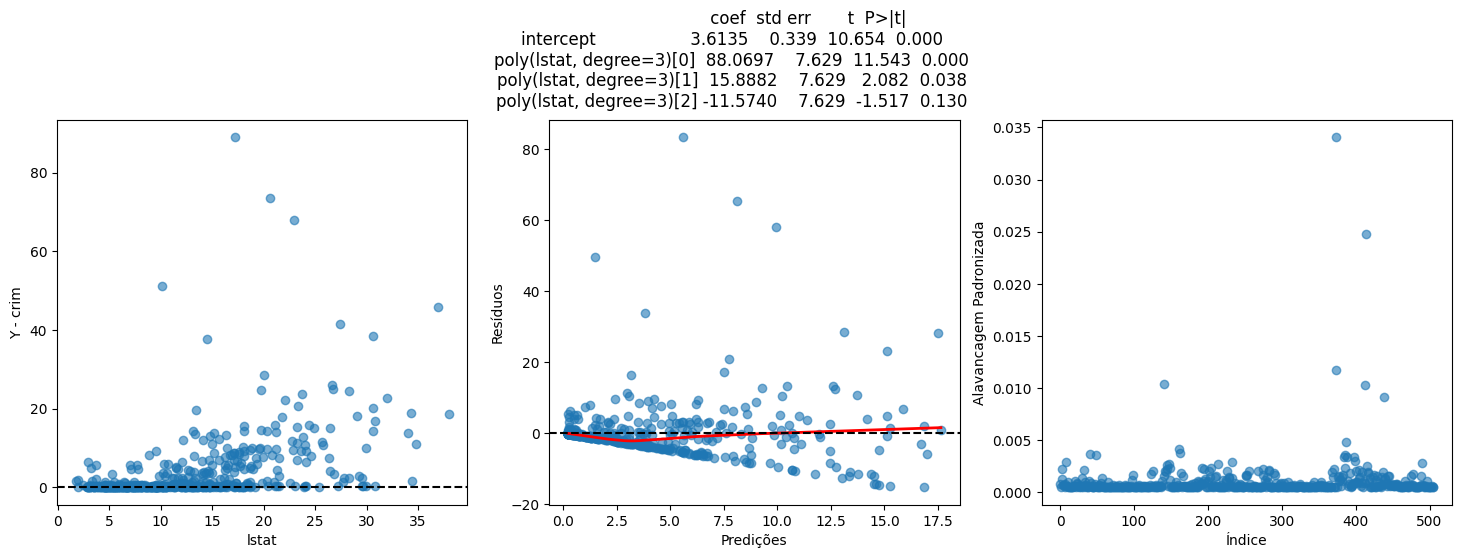

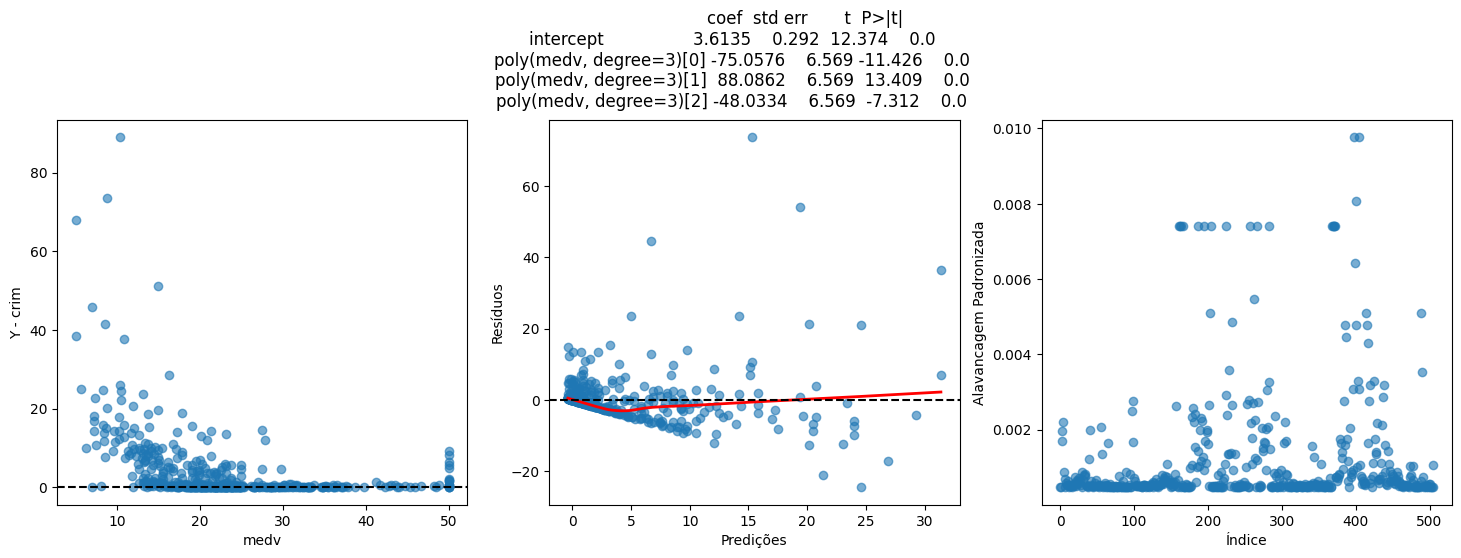

In [82]:
res_nao_linear = list()
for nome_preditor in nomes_preditores:
    regression_results = sm.OLS(y, MS([poly(nome_preditor, degree=3)]).fit_transform(Boston)).fit()
    res_nao_linear.append({'preditor':nome_preditor, 'resultado':regression_results, 'R2':regression_results.rsquared})

for r in res_nao_linear:
    fig, ax = subplots(ncols=3, figsize=(18,5))
    fig.suptitle(f'{summarize(r['resultado'])}', y=1.1)
    plot_y_preditor(y, Boston[r['preditor']], r['preditor'], ax[0])
    plot_predicao_residuos(r['resultado'], ax[1])
    plot_alavancagem(r['resultado'], ax[2])

In [91]:
informacoes = []
for nome_preditor in nomes_preditores:
    informacoes.append({'preditor': nome_preditor,
            'R2 linear': next((r['R2'] for r in res if r.get('preditor') == nome_preditor),None),
            'R2 Não-linear': next((r['R2'] for r in res_nao_linear if r.get('preditor') == nome_preditor),None),})
df = pd.DataFrame(informacoes)
df

,preditor,R2 linear,R2 Não-linear
0,zn,0.040188,0.058242
1,indus,0.165310,0.259658
2,chas,0.003124,0.003124
3,nox,0.177217,0.296978
4,rm,0.048069,0.067786
5,age,0.124421,0.174231
6,dis,0.144149,0.277825
7,rad,0.391257,0.400037
8,tax,0.339614,0.368882
9,ptratio,0.084068,0.113782


Analisando os gráficos e coparando o R2 dos modelos, os modelos com preditores transformados possuem uma melhor performance.